In [1]:
import pandas as pd
import os
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
from lib.iux001 import fetch_data, aggregation_data,merging_data1
from lib.aux001 import calc_expression
from lib.cux001 import FactorEvaluate1 as FactorEvaluate1
#from lib.cux004 import FactorEvaluate1 as FactorEvaluate4

In [3]:
method = 'bicso2'
instruments = 'rbb'
period = 5
task_id = '113001'
datasets = ['train','val']
#datasets = ['val']

In [4]:
total_data = fetch_data(method=method,
                        instruments=instruments,
                        task_id=task_id,
                        datasets=datasets)

./records/bicso2/rbb/basic/train_data.feather
./records/bicso2/rbb/basic/val_data.feather
./records/bicso2/rbb/returns/train_returns.feather
./records/bicso2/rbb/returns/val_returns.feather


In [5]:
total_data

,trade_time,code,fz002_1_2_1,fz002_10_15_1,fz002_1_2_0,fz002_10_15_0,fz002_5_10_1,fz002_5_10_0,fz002_2_3_1,fz002_2_3_0,...,openint,vwap,nxt1_ret_1h,nxt1_ret_2h,nxt1_ret_3h,nxt1_ret_5h,nxt1_ret_10h,nxt1_ret_15h,time_weight,equal_weight
0,2011-01-04 09:17:00,RB,-0.000017,0.000047,-0.000063,0.000054,0.000021,1.345755e-06,-0.000099,-0.000022,...,288396.0,4819.141997,0.000629,0.000604,0.000528,0.000428,0.000926,0.000284,0.000604,0.000587
1,2011-01-04 09:18:00,RB,0.000112,0.000042,0.000075,0.000047,0.000019,1.205453e-06,-0.000028,-0.000024,...,288464.0,4816.861594,-0.000025,-0.000100,-0.000015,-0.000253,-0.000006,-0.000358,-0.000049,-0.000047
2,2011-01-04 09:19:00,RB,0.000037,0.000039,0.000075,0.000040,0.000017,-3.356212e-07,0.000014,0.000034,...,288353.0,4819.890679,-0.000075,0.000010,-0.000175,0.000058,-0.000174,-0.000216,-0.000064,-0.000080
3,2011-01-04 09:20:00,RB,0.000012,0.000035,0.000000,0.000033,0.000014,-1.392872e-06,0.000016,0.000052,...,288504.0,4819.770149,0.000085,-0.000100,-0.000153,0.000394,-0.000272,0.000086,-0.000016,-0.000056
4,2011-01-04 09:21:00,RB,0.000150,0.000032,0.000089,0.000026,0.000014,-7.378001e-07,0.000055,0.000049,...,288413.0,4819.407115,-0.000185,-0.000238,0.000049,0.000529,-0.000373,0.000040,-0.000164,-0.000125
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1010069,2024-02-21 09:50:00,RB,0.000097,0.000030,0.000155,0.000022,0.000041,4.192218e-05,0.000136,0.000140,...,1933955.0,3749.432963,0.000251,0.000444,0.000041,-0.000694,-0.000159,0.001085,0.000280,0.000246
1010070,2024-02-21 09:51:00,RB,0.000469,0.000034,0.000286,0.000023,0.000053,4.289954e-05,0.000267,0.000166,...,1932636.0,3751.204516,0.000193,-0.000210,-0.000994,-0.000477,0.000071,0.001160,-0.000139,-0.000337
1010071,2024-02-21 09:52:00,RB,0.000156,0.000038,0.000286,0.000024,0.000062,3.983152e-05,0.000255,0.000195,...,1934525.0,3752.146055,-0.000403,-0.001187,-0.001139,-0.000485,0.000052,0.000818,-0.000787,-0.000910
1010072,2024-02-21 09:53:00,RB,0.000052,0.000038,0.000000,0.000025,0.000063,3.611792e-05,0.000168,0.000174,...,1935564.0,3752.871462,-0.000784,-0.000736,-0.000268,-0.000403,0.000468,0.001027,-0.000682,-0.000596


In [6]:
total_data.set_index(
    'trade_time'
    ).loc['2022-12-21 13:35:00':][['code','nxt1_ret_1h','nxt1_ret_2h','nxt1_ret_3h','nxt1_ret_5h']]

,code,nxt1_ret_1h,nxt1_ret_2h,nxt1_ret_3h,nxt1_ret_5h
trade_time,,,,,
2022-12-21 13:35:00,RB,0.000121,0.000182,0.000886,0.001352
2022-12-21 13:36:00,RB,0.000062,0.000766,0.001357,0.001715
2022-12-21 13:37:00,RB,0.000704,0.001295,0.001169,0.001506
2022-12-21 13:38:00,RB,0.000591,0.000465,0.000949,0.001504
2022-12-21 13:39:00,RB,-0.000125,0.000359,0.000211,0.000987
...,...,...,...,...,...
2024-02-21 09:50:00,RB,0.000251,0.000444,0.000041,-0.000694
2024-02-21 09:51:00,RB,0.000193,-0.000210,-0.000994,-0.000477
2024-02-21 09:52:00,RB,-0.000403,-0.001187,-0.001139,-0.000485


In [7]:
# total_data[['trade_time','code','oi039_1_2_1']].set_index(
#     'trade_time').loc['2021-06-08 10:04:00']

In [8]:
#total_data.set_index('trade_time').loc['2024-12-04 10:43:00':]

In [9]:
total_data.filter(regex="^nxt1").columns.to_list()
nxt1_columns = total_data.filter(regex="^nxt1").columns.to_list()
basic_columns = [
        'close', 'high', 'low', 'open', 'volume'
        #, 'value', 'openint'
    ]

regex_pattern = r'^[^_]+_(5|10|15)_.*'
not_columns = total_data.columns[total_data.columns.str.contains(
        regex_pattern)]

factor_columns = [
        col for col in total_data.columns
        if col not in ['trade_time', 'code'] + nxt1_columns + basic_columns +
        not_columns.tolist()
    ]#[0:100]

In [10]:
#total_data

In [11]:
total_data = total_data[['trade_time', 'code'] + factor_columns + basic_columns + ["nxt1_ret_{}h".format(period)]]

In [12]:
#expression = "MRANK(240,MRANK(240,'tc003_2_3_1'))"
expression = "MA(10,'iv012_1_2_1')"

In [13]:
%%time
factor_data = calc_expression(expression=expression,
                              total_data=total_data[['trade_time','code','iv012_1_2_1']].set_index('trade_time'))

CPU times: user 19.3 s, sys: 187 ms, total: 19.5 s
Wall time: 19.5 s


In [14]:
total_data

,trade_time,code,fz002_1_2_1,fz002_1_2_0,fz002_2_3_1,fz002_2_3_0,gd002_1_2_1,gd002_1_2_0,gd002_2_3_1,gd002_2_3_0,...,openint,vwap,time_weight,equal_weight,close,high,low,open,volume,nxt1_ret_5h
0,2011-01-04 09:17:00,RB,-0.000017,-0.000063,-0.000099,-0.000022,0.973237,1.000000,0.875508,0.803251,...,288396.0,4819.141997,0.000604,0.000587,3438.168162,3439.595380,3438.168162,3439.595380,1162.0,0.000428
1,2011-01-04 09:18:00,RB,0.000112,0.000075,-0.000028,-0.000024,0.148404,0.275944,0.455545,0.706601,...,288464.0,4816.861594,-0.000049,-0.000047,3438.881771,3438.881771,3436.027335,3438.168162,3049.0,-0.000253
2,2011-01-04 09:19:00,RB,0.000037,0.000075,0.000014,0.000034,0.086049,0.000000,0.267279,0.320971,...,288353.0,4819.890679,-0.000064,-0.000080,3439.595380,3440.308989,3437.454553,3438.881771,869.0,0.000058
3,2011-01-04 09:20:00,RB,0.000012,0.000000,0.000016,0.000052,0.536504,0.435348,0.376837,0.187387,...,288504.0,4819.770149,-0.000016,-0.000056,3438.881771,3440.308989,3438.881771,3439.595380,670.0,0.000394
4,2011-01-04 09:21:00,RB,0.000150,0.000089,0.000055,0.000049,0.253466,0.569728,0.321070,0.236831,...,288413.0,4819.407115,-0.000164,-0.000125,3440.308989,3440.308989,3438.168162,3438.881771,506.0,0.000529
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1010069,2024-02-21 09:50:00,RB,0.000097,0.000155,0.000136,0.000140,0.682661,0.397659,0.571893,0.456311,...,1933955.0,3749.432963,0.000280,0.000246,5049.633072,5052.326928,5048.286144,5050.980000,3058.0,-0.000694
1010070,2024-02-21 09:51:00,RB,0.000469,0.000286,0.000267,0.000166,0.124113,0.285261,0.319320,0.389490,...,1932636.0,3751.204516,-0.000139,-0.000337,5053.673856,5055.020784,5048.286144,5050.980000,7662.0,-0.000477
1010071,2024-02-21 09:52:00,RB,0.000156,0.000286,0.000255,0.000195,0.031212,0.000000,0.154582,0.176004,...,1934525.0,3752.146055,-0.000787,-0.000910,5055.020784,5056.367712,5049.633072,5052.326928,9291.0,-0.000485
1010072,2024-02-21 09:53:00,RB,0.000052,0.000000,0.000168,0.000174,0.616883,0.405033,0.384252,0.212266,...,1935564.0,3752.871462,-0.000682,-0.000596,5053.673856,5057.714640,5052.326928,5056.367712,6325.0,-0.000403


In [15]:
#factor_data.merge(total_data[['trade_time','code','nxt1_ret_15h']], on=['trade_time','code'])

In [16]:
dt = merging_data1(factor_data=factor_data,
                      returns_data=total_data,
                      period=period)

In [18]:
dt1 = dt[dt['trade_time'] > '2012-01-01']
dt1

,trade_time,transformed,code,nxt1_ret_5h
55104,2012-01-04 09:00:00,-0.000549,RB,-0.001321
55105,2012-01-04 09:01:00,-0.000358,RB,0.000268
55106,2012-01-04 09:02:00,-0.000217,RB,0.001016
55107,2012-01-04 09:03:00,-0.000199,RB,0.002071
55108,2012-01-04 09:04:00,-0.000047,RB,0.002379
...,...,...,...,...
1010068,2024-02-21 09:50:00,-0.000191,RB,-0.000694
1010069,2024-02-21 09:51:00,-0.000187,RB,-0.000477
1010070,2024-02-21 09:52:00,-0.000146,RB,-0.000485
1010071,2024-02-21 09:53:00,-0.000151,RB,-0.000403


In [20]:
evaluate1 = FactorEvaluate1(factor_data=dt1,
                                factor_name='transformed',
                                ret_name='nxt1_ret_{0}h'.format(period),
                                roll_win=15,
                                fee=0.0,
                                scale_method='roll_zscore',
                                expression=expression,
                                resampling_win=period)

In [21]:
evaluate1.run()

{'total_ret': 67.02853243723659,
 'avg_ret': 2.23599806218535e-05,
 'max_dd': -0.10527957304375579,
 'calmar': 2.55343757091401,
 'sharpe1': 0.027477820058228474,
 'sharpe2': 2.9910801143942725,
 'turnover': 0.4315504186091405,
 'win_rate': 0.5181625995041107,
 'profit_ratio': 1.1088010416750143,
 'total_ic': 0.028096027969868508,
 'ic_mean': 0.05490849114978849,
 'ic_std': 0.26219609900724106,
 'ic_ir': 0.20941765097836976,
 'factor_autocorr': 0.5460726000213602,
 'ret_autocorr': 0.03372302360766858}

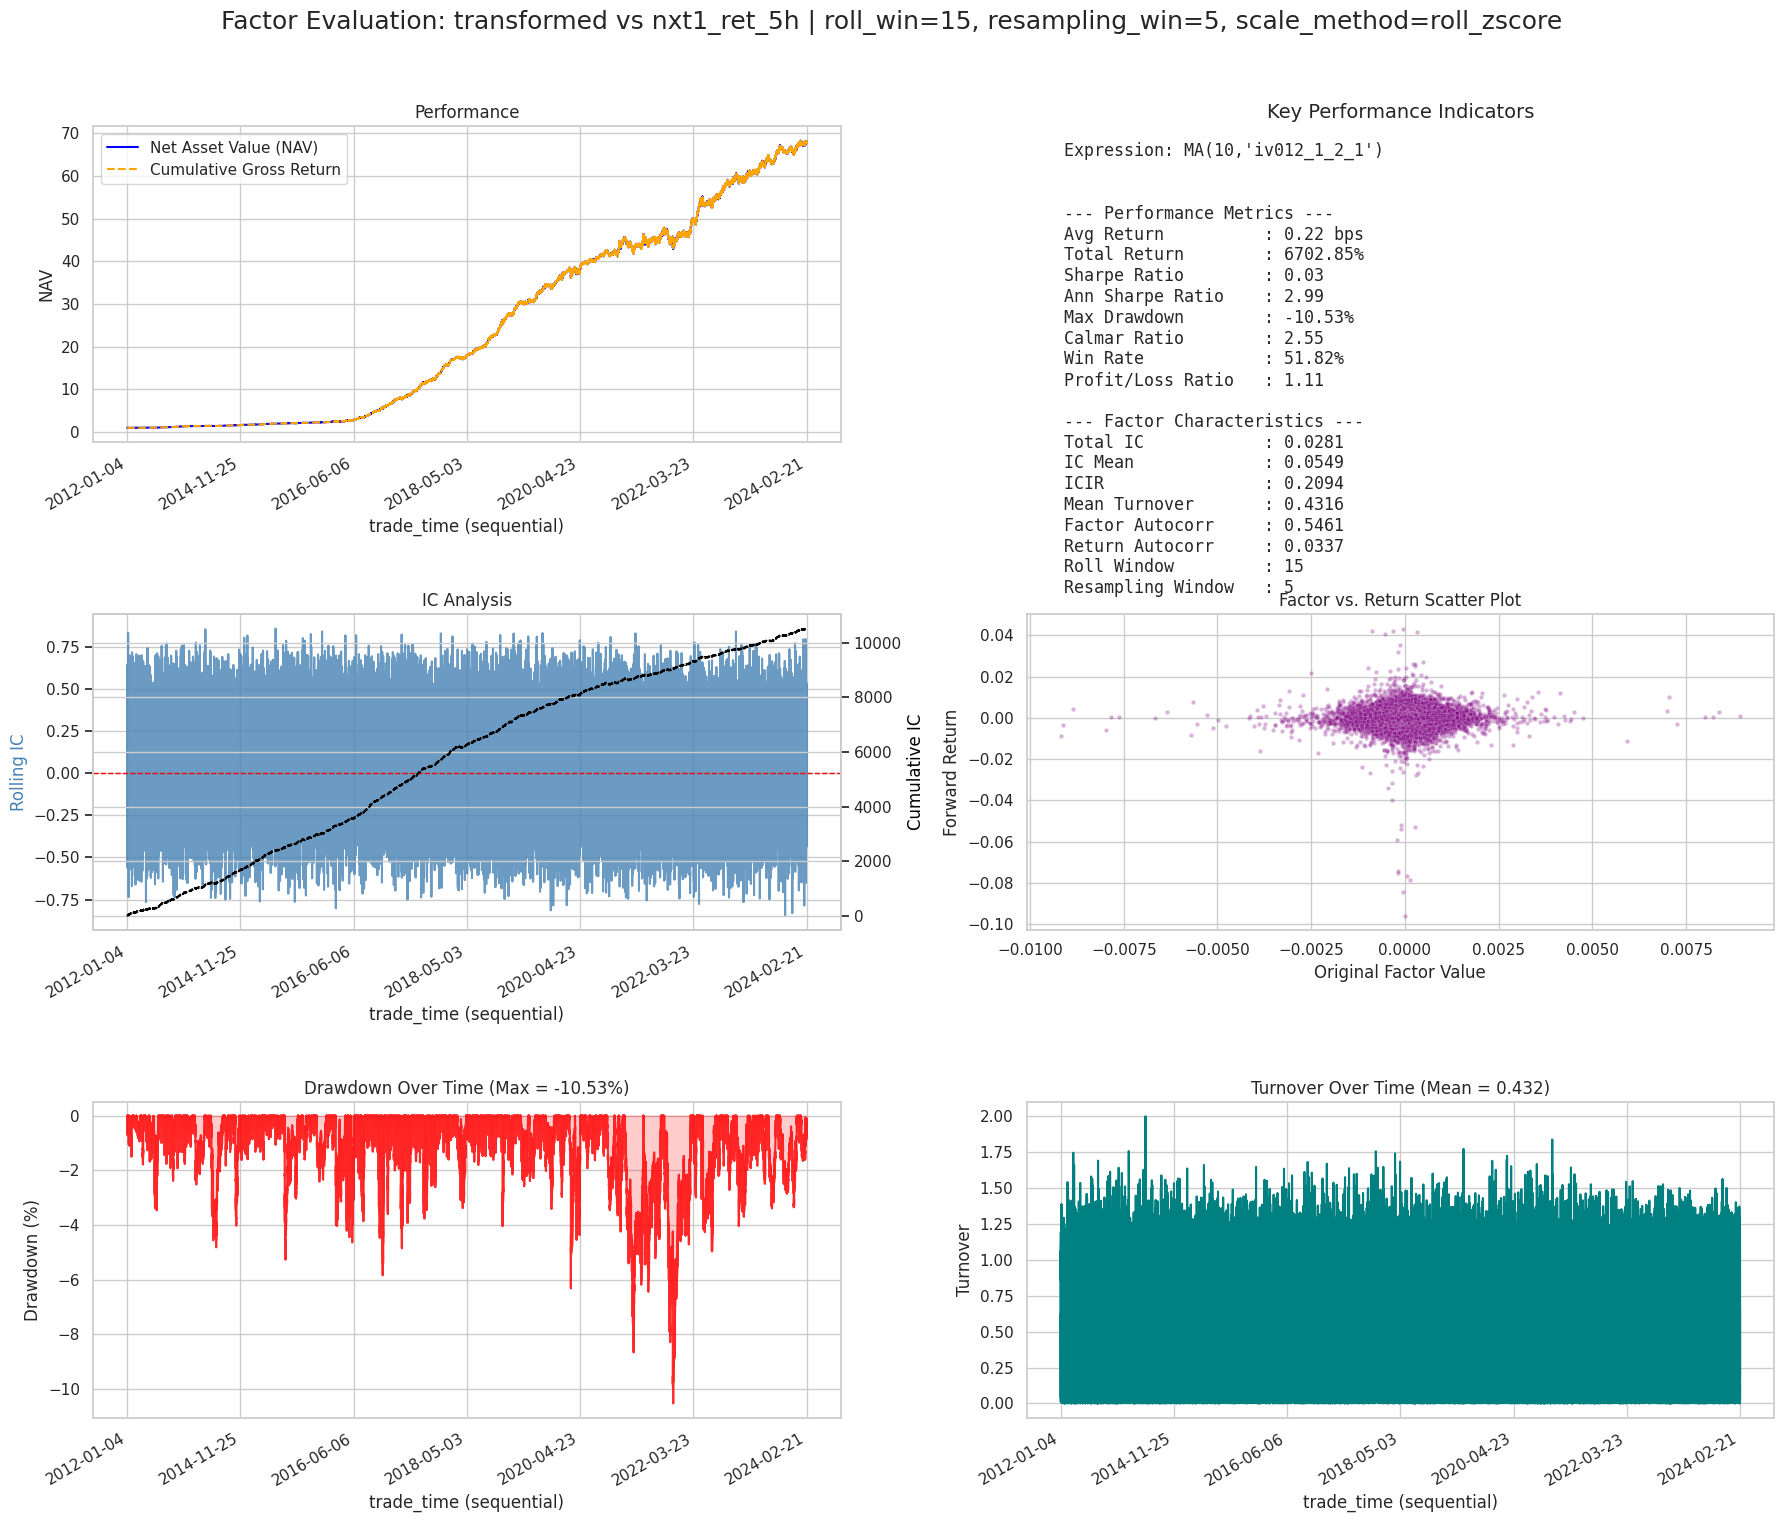

In [22]:
evaluate1.plot_results()

In [18]:
evaluate1.save_results(base_output_dir='./')

Saving results to: ./20251102_074903
Performance summary saved to: ./20251102_074903/performance_summary.txt
Saving time series data as separate files...
 -> Saved ./20251102_074903/nav.csv
 -> Saved ./20251102_074903/ic.csv
 -> Saved ./20251102_074903/turnover.csv
Evaluation plot saved to: ./20251102_074903/evaluation_plot.png
Evaluation plot also saved to: ./plot/20251102_074903.png


In [23]:
delta_days = (evaluate1.resample_data.index[-1] - evaluate1.resample_data.index[0]).days

In [26]:
years = delta_days / 365

In [29]:
ann_ret = (1 + evaluate1.resample_data['nav'].iloc[-1] - 1) ** (1 / years) - 1 #
ann_ret

0.26715944265063696

In [30]:
max_dd = (evaluate1.resample_data['nav'] / evaluate1.resample_data['nav'].cummax() -
                  1).min()
max_dd

-0.1615508011172847

In [31]:
ann_ret / abs(max_dd)

1.6537178448077219

In [32]:
evaluate1.resample_data

,transformed,nxt1_ret_5h,f_scaled,ic,cumsum_ic,pos,gross_ret,turnover,net_ret,nav
trade_time,,,,,,,,,,
2011-01-04 09:20:00,0.126883,0.000394,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-01-04 09:25:00,0.577287,-0.000666,-0.469340,NaN,NaN,-0.469340,0.000313,NaN,NaN,NaN
2011-01-04 09:30:00,1.095944,0.000358,-0.511118,NaN,NaN,-0.511118,-0.000183,0.041778,-0.000183,0.999817
2011-01-04 09:35:00,1.799741,-0.000109,-0.446699,NaN,NaN,-0.446699,0.000049,0.064419,0.000049,0.999865
2011-01-04 09:40:00,2.697456,0.000467,-0.270207,0.288929,0.288929,-0.270207,-0.000126,0.176491,-0.000126,0.999739
...,...,...,...,...,...,...,...,...,...,...
2024-02-21 09:30:00,7.091149,0.000226,-0.482457,-0.446571,-51419.700357,-0.482457,-0.000109,0.931870,-0.000109,22.429100
2024-02-21 09:35:00,7.170121,0.000865,0.470528,-0.450446,-51420.150803,0.470528,0.000407,0.952985,0.000407,22.438226
2024-02-21 09:40:00,7.555766,0.000617,-0.506395,-0.376140,-51420.526942,-0.506395,-0.000313,0.976923,-0.000313,22.431211


In [34]:
evaluate1.resample_data['ic'] 

trade_time
2011-01-04 09:20:00         NaN
2011-01-04 09:25:00         NaN
2011-01-04 09:30:00         NaN
2011-01-04 09:35:00         NaN
2011-01-04 09:40:00    0.288929
                         ...   
2024-02-21 09:30:00   -0.446571
2024-02-21 09:35:00   -0.450446
2024-02-21 09:40:00   -0.376140
2024-02-21 09:45:00    0.205909
2024-02-21 09:50:00    0.217221
Name: ic, Length: 204556, dtype: float64